## Introduction

Predict whether a pacient has diabetes. This is a shorter version of the also known as "Diabetes" dataset.

In [ ]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import math
import csv
from deap import creator, base, tools
from sklearn.preprocessing import StandardScaler

## Dataset

**Class:**

output: 1, 0.


**Listing of features:**

HighBP

HighChol

CholCheck

BMI

Smoker

Stroke

HeartDiseaseorAttack

PhysActivity

Fruits

Veggies

HvyAlcoholConsump

AnyHealthcare

NoDocbcCost

GenHlth

MentHlth

PhysHlth

DiffWalk

Sex

Age

Education

Income

### Load the dataset

In [ ]:
# Suppressing Warnings:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
## mount your Google drive
# 1) run this cell
# 2) sign in
# 3) verify your drive is mounted

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


Clone the GRAPE repository at first because the dataset to be used is already there.

In [ ]:
import os
# Get the library from our BDS research Group
# copy the path from your drive
PATH = '/content/drive/MyDrive/grape/'

# check if 'grape' already exists
if os.path.exists(PATH):
    print('grape directory already exists')
else:
    %cd /content/drive/MyDrive/
    !git clone https://github.com/bdsul/grape.git
    print('Cloning grape in your Drive')

# change directory to 'grape'
%cd /content/drive/MyDrive/grape/

grape directory already exists
/content/drive/MyDrive/grape


Now you have a grape folder in your Drive account.

Upload the files training.csv and test.csv from the competition to the folder grape/datasets in your Drive before running the next cells.

### Train set

In [ ]:
train_file = 'datasets/training.csv'

In [ ]:
# load train set
df_train = pd.read_csv(PATH+train_file)
df_train.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,output
0,0.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,7.0,6.0,8.0,0.0
1,1.0,1.0,1.0,35.0,0.0,0.0,1.0,1.0,1.0,1.0,...,0.0,2.0,0.0,0.0,0.0,1.0,9.0,6.0,8.0,0.0
2,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,2.0,0.0,0.0,1.0,0.0,13.0,5.0,4.0,0.0
3,0.0,0.0,1.0,24.0,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,2.0,0.0,0.0,0.0,1.0,7.0,4.0,6.0,0.0
4,1.0,0.0,1.0,41.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,3.0,3.0,0.0,0.0,0.0,8.0,5.0,7.0,0.0


In [ ]:
df_train.describe()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,output
count,5042.000000,5042.000000,5042.000000,5042.000000,5042.000000,5042.000000,5042.000000,5042.000000,5042.000000,5042.000000,...,5042.000000,5042.000000,5042.000000,5042.000000,5042.000000,5042.000000,5042.000000,5042.000000,5042.000000,5042.000000
mean,0.513883,0.493653,0.972035,29.447441,0.473225,0.050377,0.133082,0.728877,0.616025,0.801666,...,0.085879,2.702102,3.617017,5.195954,0.207061,0.447441,8.376041,4.958548,5.852836,0.356010
std,0.499857,0.500009,0.164889,7.080019,0.499332,0.218743,0.339697,0.444583,0.486400,0.398785,...,0.280213,1.106379,7.997166,9.538762,0.405240,0.497279,2.920253,1.018217,2.131317,0.478866
min,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,1.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,7.000000,4.000000,4.000000,0.000000
50%,1.000000,0.000000,1.000000,28.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,9.000000,5.000000,6.000000,0.000000
75%,1.000000,1.000000,1.000000,33.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,3.000000,2.000000,5.000000,0.000000,1.000000,10.000000,6.000000,8.000000,1.000000
max,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000,1.000000


In [ ]:
test_file = 'datasets/test.csv'
# load test set
df_test = pd.read_csv(PATH+test_file)
df_test.head()
df_test.describe()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,95804.000000,95804.000000,95804.000000,95804.000000,95804.000000,95804.000000,95804.000000,95804.000000,95804.000000,95804.000000,...,95804.000000,95804.000000,95804.000000,95804.000000,95804.000000,95804.000000,95804.000000,95804.000000,95804.000000,95804.000000
mean,0.508330,0.484239,0.970628,29.262797,0.461442,0.053839,0.125329,0.724427,0.621352,0.798161,...,0.953353,0.088973,2.701891,3.488654,5.155662,0.219573,0.447841,8.362761,4.977642,5.846739
std,0.499933,0.499754,0.168849,6.972092,0.498514,0.225701,0.331093,0.446805,0.485053,0.401375,...,0.210883,0.284707,1.106275,7.819002,9.550624,0.413960,0.497275,2.959191,1.012794,2.136366
min,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,1.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,7.000000,4.000000,4.000000
50%,1.000000,0.000000,1.000000,28.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,9.000000,5.000000,6.000000
75%,1.000000,1.000000,1.000000,32.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,5.000000,0.000000,1.000000,11.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [ ]:
train_data = df_train.dropna()
test_data = df_test.fillna(df_train.mean())

In [ ]:
# Separate features and target in training data
features = train_data.columns.drop('output')
X_train = train_data[features]
y_train = train_data['output']

In [ ]:
from sklearn.preprocessing import StandardScaler
# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(test_data[features])

# Transpose datasets for GRAPE compatibility
X_train, X_test = X_train.T, X_test.T

In [ ]:
# Define functions for protected division and math operations
def pdiv(a, b):
    return a / b if b != 0 else 1

function_map = {
    "sin": math.sin,
    "cos": math.cos,
    "exp": math.exp,
    "log": math.log,
    "sqrt": math.sqrt
}


### Test set

Convert the datasets to NumPy to easily use them.

## GRAPE

<div>
<img src="https://drive.google.com/uc?export=view&id=1hw43Oi3lGTCkspQ0ged2bZB8q2EpcPhz" width="150"/>
</div>

GRammatical Algorithms in Python for Evolution (GRAPE)


In [ ]:
!pip install deap

import grape
import algorithms

from os import path
from deap import creator, base, tools
import random
import csv
from algorithms import ge_eaSimpleWithElitism

You can import functions to be used with your grammar from [functions.py](https://github.com/UL-BDS/grape/blob/main/functions.py) on GRAPE repository and / or you can define your own functions.

'heartDisease.bnf' is a grammar used for another problem just to check if everything is working well.

Write your own grammar in a text file and save it in your Drive account.

Put the whole address on GRAMMAR_FILE and print to check it.

In [ ]:
# Define GRAPE Parameters
POPULATION_SIZE = 500
MAX_GENERATIONS = 50
P_CROSSOVER = 0.8
P_MUTATION = 0.05
ELITE_SIZE = 5
HALLOFFAME_SIZE = 5
TOURNAMENT_SIZE = 3
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

In [ ]:
GRAMMAR_FILE = '/content/drive/MyDrive/grape/grammars/diabetes.bnf' #put the whole address of your own grammar and remove the # in the beginning of this line
# GRAMMAR_FILE = 'heartDisease.bnf' #remove this line when you are using your own grammar

f = open(GRAMMAR_FILE, "r") #remove the # in the beginning of this line when you are using your own grammar
# f = open("grammars/" + GRAMMAR_FILE, "r") #remove this line when you are using your own grammar
print(f.read())
f.close()


<start> ::= <expr>

<expr> ::= <expr> + <expr> | <expr> - <expr> | <expr> * <expr> | pdiv(<expr>, <expr>) | <func>(<expr>) | <terminal> | <constant>

<func> ::= sin | cos | exp | log | sqrt

<terminal> ::= HighBP | HighChol | CholCheck | BMI | Smoker | Stroke | HeartDiseaseorAttack | PhysActivity | Fruits | Veggies | HvyAlcoholConsump | AnyHealthcare | NoDocbcCost | GenHlth | MentHlth | PhysHlth | DiffWalk | Sex | Age | Education | Income

<constant> ::= 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 0.5 | 2.5 | 3.14 | 1.618 | 0.1 | 0.01 | 100 | 1000



Run the following cell to put your grammar on the class Grammar.

In [ ]:
BNF_GRAMMAR = grape.Grammar(GRAMMAR_FILE) #remove the # in the beginning of this line when you are using your own grammar
# BNF_GRAMMAR = grape.Grammar(path.join("grammars", GRAMMAR_FILE)) #remove this line when you are using your own grammar

The fitness function here is the percentage of outputs wrongly predicted.

You can write your own fitness function if you prefer.

In [ ]:
# Example of preparing the feature dictionary
def create_feature_dict(X, index):
    feature_names = ["HighBP", "HighChol", "CholCheck", "BMI", "Smoker",
                     "Stroke", "HeartDiseaseorAttack", "PhysActivity", "Fruits",
                     "Veggies", "HvyAlcoholConsump", "AnyHealthcare", "NoDocbcCost",
                     "GenHlth", "MentHlth", "PhysHlth", "DiffWalk", "Sex",
                     "Age", "Education", "Income"]

    # Select the column values for the current sample (index)
    feature_values = X[:, index]
    return dict(zip(feature_names, feature_values))


In [ ]:
def fitness_eval(individual, points):
    X, Y = points
    if individual.invalid:
        return np.NaN,

    try:
        # Iterate over each sample and evaluate predictions
        predictions = []
        for i in range(X.shape[1]):  # Iterate over columns (samples)
            feature_dict = create_feature_dict(X, i)
            pred = eval(individual.phenotype, {}, feature_dict)  # Use feature_dict for eval
            predictions.append(pred)

        # Calculate fitness as the proportion of correct predictions
        predictions = np.array(predictions)
        fitness = 1 - np.mean(np.equal(Y, predictions))
        return fitness,

    except (FloatingPointError, ZeroDivisionError, OverflowError, MemoryError, NameError) as e:
        return np.NaN,


In [ ]:
# Set up DEAP components for GRAPE
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", grape.Individual, fitness=creator.FitnessMin)
toolbox = base.Toolbox()
toolbox.register("populationCreator", grape.sensible_initialisation, creator.Individual)
toolbox.register("evaluate", fitness_eval)
toolbox.register("select", tools.selTournament, tournsize=TOURNAMENT_SIZE)
toolbox.register("mate", grape.crossover_onepoint)
toolbox.register("mutate", grape.mutation_int_flip_per_codon)

To use properly the fitness function above with GRAPE, the features must be in the lines, and the samples must be in the columns, so if your data is not like that, you need to transpose the matrix.

Take a look at the print. If you run this cell two times, the matrix will be transposed again and will not work properly.

Set the Grammatical Evolution parameters.

Make sure you set a random seed just in case we need to re-run your experiments.

Create a toolbox.

In [ ]:
# Initialize population
try:
    population = toolbox.populationCreator(
        pop_size=POPULATION_SIZE,
        bnf_grammar=BNF_GRAMMAR,
        min_init_depth=4,
        max_init_depth=8,
        codon_size=255,
        codon_consumption='lazy',
        genome_representation='list'
    )

    # Set up Hall of Fame and Statistics
    hof = tools.HallOfFame(HALLOFFAME_SIZE)
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.nanmean)
    stats.register("std", np.nanstd)
    stats.register("min", np.nanmin)
    stats.register("max", np.nanmax)

    # Run Grammatical Evolution
    population, logbook = ge_eaSimpleWithElitism(
        population, toolbox, cxpb=P_CROSSOVER, mutpb=P_MUTATION,
        ngen=MAX_GENERATIONS, elite_size=ELITE_SIZE,
        bnf_grammar=BNF_GRAMMAR, codon_size=255, max_tree_depth=17,
        max_genome_length=50, points_train=[X_train, y_train],
        codon_consumption='lazy', report_items=['gen', 'avg', 'std', 'min', 'max'],
        genome_representation='list', stats=stats, halloffame=hof, verbose=True
    )

    # Display best individual
    best = hof.items[0].phenotype
    print("Best individual:", best)
    print("Training Fitness:", hof.items[0].fitness.values[0])

except IndexError as e:
    print("Error during population creation or evolution:", e)
    print("BNF_GRAMMAR keys:", BNF_GRAMMAR.keys())
    print("Initialization parameters:", POPULATION_SIZE, 4, 8)

gen	invalid	avg    	std      	min    	max	best_ind_length	avg_length	best_ind_nodes	avg_nodes	best_ind_depth	avg_depth	avg_used_codons	best_ind_used_codons	behavioural_diversity	structural_diversity	fitness_diversity	selection_time	generation_time
0  	0      	0.99288	0.0498413	0.64399	1  	3              	4.82      	1             	1.42667  	4             	4.38     	3.28           	2                   	0                    	0.154               	0                	0             	21.8393        
1  	67     	0.971223	0.0970397	0.64399	1  	3              	4.64203   	1             	1.19861  	4             	4.18245  	2.59584        	2                   	0                    	0.174               	0                	0.00321198    	19.7545        
2  	50     	0.940533	0.132795 	0.64399	1  	3              	4.65702   	1             	1.12472  	4             	4.11804  	2.37416        	2                   	0                    	0.134               	0                	0.00201011    	18.9401        
3  	33

In [ ]:
print(hof.items[0])

In [ ]:
# Prediction function
def predict(individual, X):
    predictions = []
    for i in range(X.shape[1]):  # Iterate over each sample (column)
        feature_dict = create_feature_dict(X, i)
        try:
            # Evaluate the expression using the feature dictionary for each sample
            pred = eval(individual.phenotype, {}, feature_dict)
            predictions.append(pred)
        except (FloatingPointError, ZeroDivisionError, OverflowError, MemoryError, NameError):
            predictions.append(np.NaN)  # Append NaN if evaluation fails

    return np.array(predictions)  # Return predictions as an array


# Predict and prepare submission
y_pred = predict(hof.items[0], X_test)
submission = pd.DataFrame({'index': range(len(y_pred)), 'output': y_pred})
submission.to_csv('submission.csv', index=False)
print("Submission file saved as 'submission.csv'")

Submission file saved as 'submission.csv'


Run Grammatical Evolution.

Show the best individual as an expression.

Define a function to predict values, without comparing to expected outputs.

Predict the classes of the test set.

Make sure you print here in the notebook you will submit to Brightspace the same predictions you used in your best submission to the Kaggle competition.

Write a code to create a .csv with the following format:
1. First column is the index (from 0 to 95803);
2. Second column is named `output` and contains the predictions (only 0's or 1's) you  got in the previous cell with y_pred.

Example:

    index,output

    0,0

    1,0

    2,1

    ...

    95803,0


Submit it to the competition and check your score there.

## Genetic Programming

If you do not want to use GE, you can use GP in this project.

In [ ]:
!pip install gplearn
from deap import gp
from deap import algorithms
#base, creator and tools were already imported
from gplearn.genetic import SymbolicClassifier

Set GP parameters.

Next steps:

1. Define a fitness function;
2. Add functions and terminals to `gp.PrimitiveSet`. Maybe you will need to define some functions before that;
3. Create the toolbox;
4. Run GP;
5. Define a function to predict samples using a GP individual;
6. Predict the test set, save a .csv file and submit it in the Kaggle competition to see if your results are better than those from people using GE.

Hint:
    
    Maybe you will need to change the format of the data on X_train and X_test.

Clean your notebook!

If you are using GE, remove the cells for GP, and vice-versa.

In [ ]:

# Load training and test data
train_data = pd.read_csv(PATH+train_file)
test_data = pd.read_csv(PATH+test_file)

# Check data shapes
print(f'Training data shape: {train_data.shape}')
print(f'Test data shape: {test_data.shape}')
train_data.head()


Training data shape: (5042, 22)
Test data shape: (95804, 21)


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,output
0,0.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,7.0,6.0,8.0,0.0
1,1.0,1.0,1.0,35.0,0.0,0.0,1.0,1.0,1.0,1.0,...,0.0,2.0,0.0,0.0,0.0,1.0,9.0,6.0,8.0,0.0
2,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,2.0,0.0,0.0,1.0,0.0,13.0,5.0,4.0,0.0
3,0.0,0.0,1.0,24.0,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,2.0,0.0,0.0,0.0,1.0,7.0,4.0,6.0,0.0
4,1.0,0.0,1.0,41.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,3.0,3.0,0.0,0.0,0.0,8.0,5.0,7.0,0.0


In [ ]:

# Handle missing values if any
train_data = train_data.dropna()
test_data = test_data.fillna(train_data.mean())

# Normalize or scale features if needed (for example purposes)
from sklearn.preprocessing import StandardScaler

features = train_data.columns.drop('output')
scaler = StandardScaler()
train_data[features] = scaler.fit_transform(train_data[features])
test_data[features] = scaler.transform(test_data[features])


In [ ]:

# Example GP/GE classifier setup
from gplearn.genetic import SymbolicClassifier
import random
from gplearn.functions import make_function

# Set random seed for reproducibility
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)

# Define a protected division function
def protected_div(x1, x2):
    return np.divide(x1, x2, out=np.ones_like(x1), where=x2 != 0)

# Add protected division to the function set
protected_div_func = make_function(function=protected_div, name='protected_div', arity=2)

# Define the classifier using Genetic Programming (adjust parameters as needed)
gp_classifier = SymbolicClassifier(
    generations=50,
    population_size=1000,
    tournament_size=8,  # Increase selection pressure
    function_set=['add', 'sub', 'mul', protected_div_func, 'sqrt', 'log', 'abs', 'max', 'min'],
    parsimony_coefficient=0.0005,  # Adjust to control complexity
    stopping_criteria=0.001,  # Stop early if fitness improvement is minimal
    const_range=(-5.0, 5.0),  # Allow ephemeral constants
    p_crossover=0.9,
    p_subtree_mutation=0.05,
    p_hoist_mutation=0.02,
    p_point_mutation=0.03,
    n_jobs=-1,  # Use all processors
    random_state=random_seed,
    verbose=1
)

# Separate features and target for training
X_train = train_data.drop('output', axis=1)
y_train = train_data['output']


In [ ]:

# Train the model
gp_classifier.fit(X_train, y_train)

# Display the best program (model) found
print("Best program found:", gp_classifier._program)


    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    12.45          1.18819        3         0.574694              N/A      1.36m
   1     8.44         0.782641        3         0.574694              N/A      1.43m
   2     7.07         0.714118        5         0.556378              N/A      1.54m
   3     8.16         0.666319       13         0.541053              N/A      1.55m
   4     9.02         0.627467       11         0.543886              N/A      1.36m
   5    10.49         0.595663       21         0.535479              N/A      1.11m
   6    11.50         0.590034       15         0.531279              N/A      1.41m
   7    13.74         0.569301       11           0.5261              N/A      1.40m
   8    14.42          0.57538       13         0.524238              N/A  

In [ ]:

# Generate predictions for the test data
X_test = test_data.copy()
test_predictions = gp_classifier.predict(X_test)

# Prepare submission file
submission = pd.DataFrame({
    'index': range(len(test_predictions)),
    'output': test_predictions
})
submission.to_csv('submission2.csv', index=False)
print("Submission file saved as 'submission2.csv'.")


Submission file saved as 'submission2.csv'.


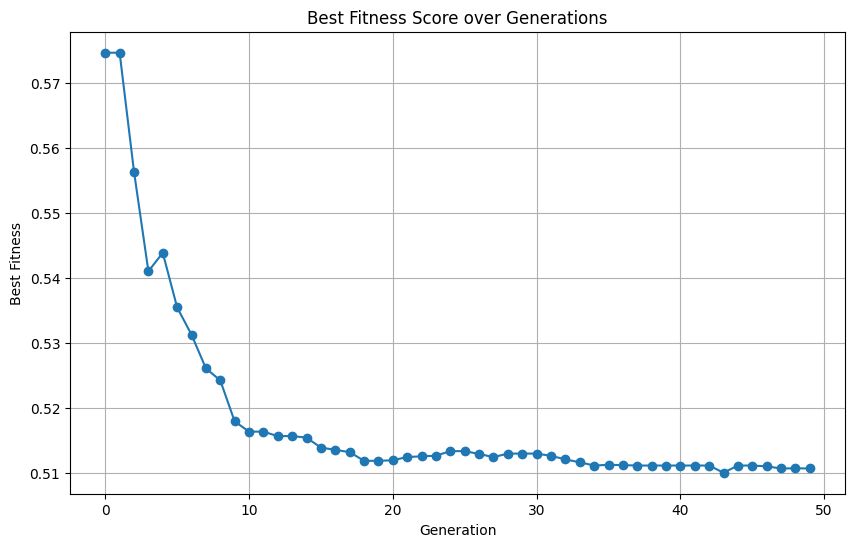

In [ ]:
# Extract best fitness over generations from run_details_
fitness_over_gens = gp_classifier.run_details_['best_fitness']

# Plot the best fitness score per generation
plt.figure(figsize=(10, 6))
plt.plot(range(len(fitness_over_gens)), fitness_over_gens, marker='o', linestyle='-')
plt.xlabel('Generation')
plt.ylabel('Best Fitness')
plt.title('Best Fitness Score over Generations')
plt.grid(True)
plt.show()